In [2]:
import pandas as pd

# Load the data from the Excel file
data = pd.read_excel('HW7_data.xlsx')

In [6]:
porosity = data['Porosity']
permeability = data['Permeability']
ln_porosity = data['ln porosity']
ln_permeability = data['ln permeability']

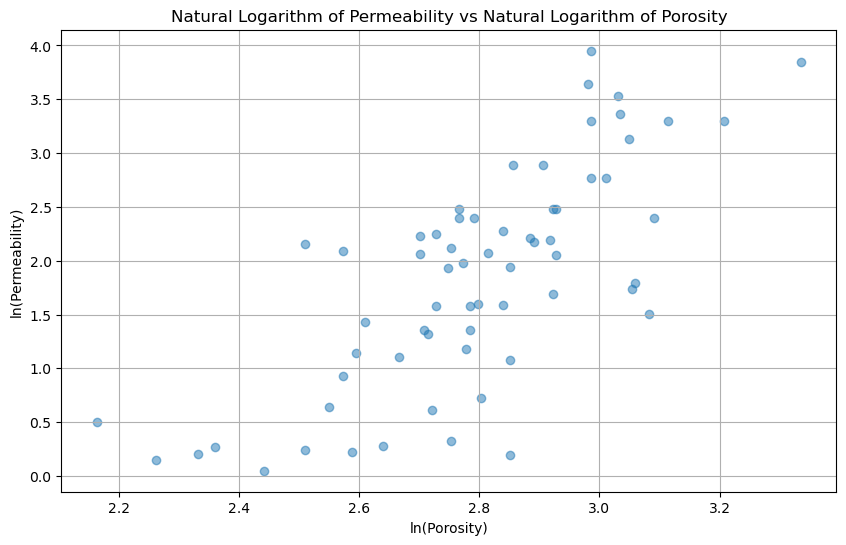

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(ln_porosity, ln_permeability, alpha=0.5)
plt.title('Natural Logarithm of Permeability vs Natural Logarithm of Porosity')
plt.xlabel('ln(Porosity)')
plt.ylabel('ln(Permeability)')
plt.grid(True)
plt.show()

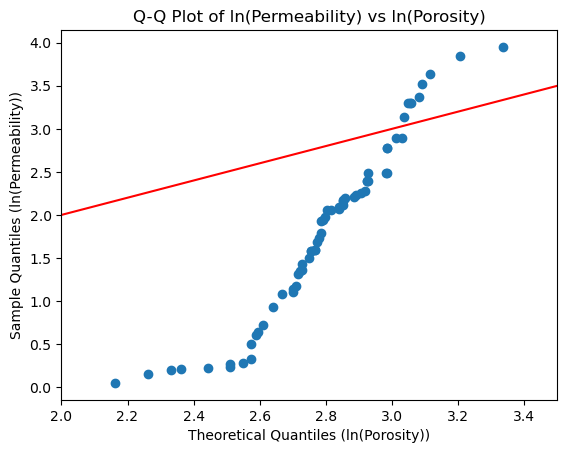

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Load the data from the Excel file
data = pd.read_excel('HW7_data.xlsx')

porosity = data['Porosity']
permeability = data['Permeability']
ln_porosity = data['ln porosity']
ln_permeability = data['ln permeability']

# Create the Q-Q plot
sm.qqplot_2samples(ln_porosity, ln_permeability, line='45')
plt.title('Q-Q Plot of ln(Permeability) vs ln(Porosity)')
plt.xlabel('Theoretical Quantiles (ln(Porosity))')
plt.ylabel('Sample Quantiles (ln(Permeability))')

# Set the x-axis limits
plt.xlim(2, 3.5)

plt.show()

Intercept (b0): -7.7308
Slope (b1): 3.4222
Regression Equation: ln(Permeability) = -7.7308 + 3.4222 * ln(Porosity)


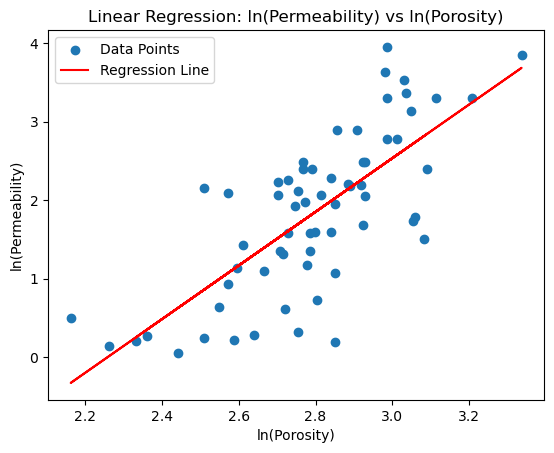

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data from the Excel file
data = pd.read_excel('HW7_data.xlsx')

ln_porosity = data['ln porosity']
ln_permeability = data['ln permeability']

# Calculate the regression coefficients (b0 and b1)
n = len(ln_porosity)
mean_x = np.mean(ln_porosity)
mean_y = np.mean(ln_permeability)

# Calculate the slope (b1) and intercept (b0)
numerator = np.sum((ln_porosity - mean_x) * (ln_permeability - mean_y))
denominator = np.sum((ln_porosity - mean_x) ** 2)
b1 = numerator / denominator
b0 = mean_y - b1 * mean_x

# Print the regression coefficients
print(f"Intercept (b0): {b0:.4f}")
print(f"Slope (b1): {b1:.4f}")

# Print the regression equation
print(f"Regression Equation: ln(Permeability) = {b0:.4f} + {b1:.4f} * ln(Porosity)")

# Plot the data points
plt.scatter(ln_porosity, ln_permeability, label='Data Points')

# Plot the regression line
regression_line = b0 + b1 * ln_porosity
plt.plot(ln_porosity, regression_line, color='red', label='Regression Line')

# Add labels and title
plt.title('Linear Regression: ln(Permeability) vs ln(Porosity)')
plt.xlabel('ln(Porosity)')
plt.ylabel('ln(Permeability)')
plt.legend()

# Show the plot
plt.show()

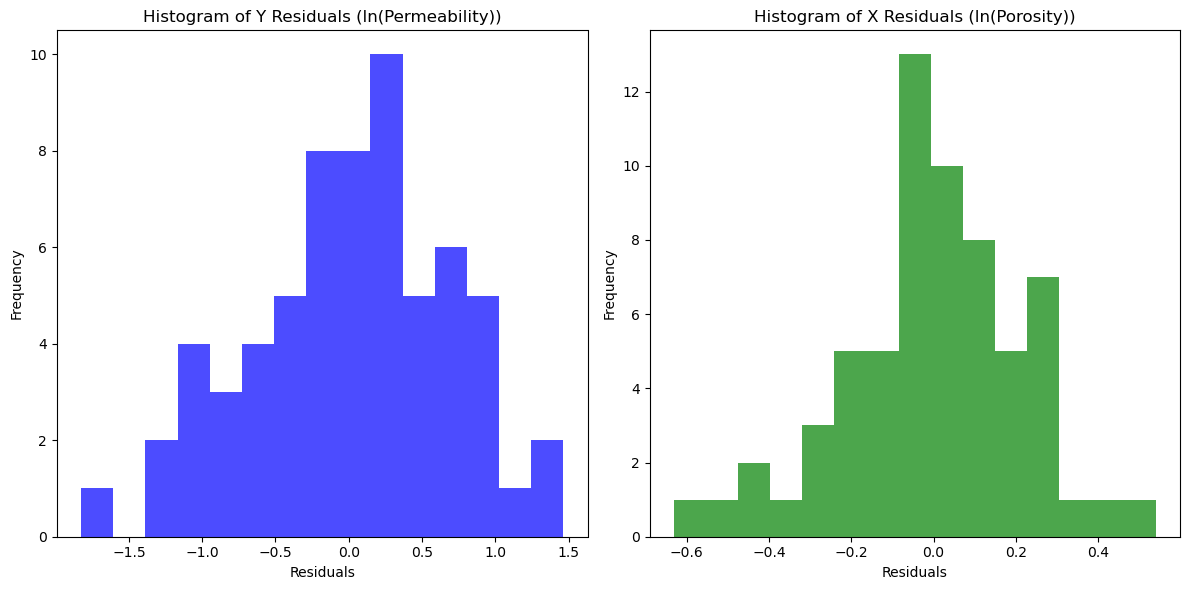

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data from the Excel file
data = pd.read_excel('HW7_data.xlsx')

ln_porosity = data['ln porosity']
ln_permeability = data['ln permeability']

# Calculate the regression coefficients (b0 and b1)
n = len(ln_porosity)
mean_x = np.mean(ln_porosity)
mean_y = np.mean(ln_permeability)

numerator = np.sum((ln_porosity - mean_x) * (ln_permeability - mean_y))
denominator = np.sum((ln_porosity - mean_x) ** 2)
b1 = numerator / denominator
b0 = mean_y - b1 * mean_x

# Calculate the predicted values
predicted_ln_permeability = b0 + b1 * ln_porosity

# Calculate the residuals
residuals_y = ln_permeability - predicted_ln_permeability
residuals_x = ln_porosity - mean_x

# Plot histograms of the residuals
plt.figure(figsize=(12, 6))

# Histogram of Y residuals
plt.subplot(1, 2, 1)
plt.hist(residuals_y, bins=15, color='blue', alpha=0.7)
plt.title('Histogram of Y Residuals (ln(Permeability))')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Histogram of X residuals
plt.subplot(1, 2, 2)
plt.hist(residuals_x, bins=15, color='green', alpha=0.7)
plt.title('Histogram of X Residuals (ln(Porosity))')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, norm

# Load the data from the Excel file
data = pd.read_excel('HW7_data.xlsx')

ln_porosity = data['ln porosity']
ln_permeability = data['ln permeability']

# Calculate the regression coefficients (b0 and b1)
n = len(ln_porosity)
mean_x = np.mean(ln_porosity)
mean_y = np.mean(ln_permeability)

numerator = np.sum((ln_porosity - mean_x) * (ln_permeability - mean_y))
denominator = np.sum((ln_porosity - mean_x) ** 2)
b1 = numerator / denominator
b0 = mean_y - b1 * mean_x

# Calculate the predicted values
predicted_ln_permeability = b0 + b1 * ln_porosity

# Calculate the Y residuals
residuals_y = ln_permeability - predicted_ln_permeability

# Perform the Chi-square test for normality
def chi_square_test_for_normality(data, num_bins=10, confidence_level=0.90):
    # Calculate observed frequencies
    observed_frequencies, bin_edges = np.histogram(data, bins=num_bins)
    
    # Calculate expected frequencies for a normal distribution
    mean = np.mean(data)
    std_dev = np.std(data)
    expected_frequencies = []
    for i in range(num_bins):
        z1 = (bin_edges[i] - mean) / std_dev
        z2 = (bin_edges[i+1] - mean) / std_dev
        expected_frequencies.append(n * (norm.cdf(z2) - norm.cdf(z1)))
    
    # Calculate the Chi-square statistic
    chi_square_stat = np.sum((observed_frequencies - expected_frequencies) ** 2 / expected_frequencies)
    
    # Degrees of freedom
    df = num_bins - 1
    
    # Critical value from Chi-square distribution
    critical_value = chi2.ppf(confidence_level, df)
    
    # Compare Chi-square statistic to critical value
    if chi_square_stat < critical_value:
        print(f"Chi-square statistic: {chi_square_stat:.4f}")
        print(f"Critical value: {critical_value:.4f}")
        print("The residuals are normally distributed at the 90% confidence level.")
    else:
        print(f"Chi-square statistic: {chi_square_stat:.4f}")
        print(f"Critical value: {critical_value:.4f}")
        print("The residuals are not normally distributed at the 90% confidence level.")

# Perform the Chi-square test on Y residuals
chi_square_test_for_normality(residuals_y)

Chi-square statistic: 4.6511
Critical value: 14.6837
The residuals are normally distributed at the 90% confidence level.


In [24]:
import pandas as pd
import numpy as np
from scipy.stats import chi2, norm

# Load the data from the Excel file
data = pd.read_excel('HW7_data.xlsx')

ln_porosity = data['ln porosity']
ln_permeability = data['ln permeability']

# Calculate the regression coefficients (b0 and b1)
n = len(ln_porosity)
mean_x = np.mean(ln_porosity)
mean_y = np.mean(ln_permeability)

numerator = np.sum((ln_porosity - mean_x) * (ln_permeability - mean_y))
denominator = np.sum((ln_porosity - mean_x) ** 2)
b1 = numerator / denominator
b0 = mean_y - b1 * mean_x

# Calculate the predicted values
predicted_ln_permeability = b0 + b1 * ln_porosity

# Calculate the Y residuals
residuals_y = ln_permeability - predicted_ln_permeability

# Perform the Chi-square test for normality
def chi_square_test_for_normality(data, num_bins=3, confidence_level=0.90):
    # Calculate observed frequencies
    observed_frequencies, bin_edges = np.histogram(data, bins=num_bins)
    
    # Calculate expected frequencies for a normal distribution
    mean = np.mean(data)
    std_dev = np.std(data)
    expected_frequencies = []
    for i in range(num_bins):
        z1 = (bin_edges[i] - mean) / std_dev
        z2 = (bin_edges[i+1] - mean) / std_dev
        expected_frequencies.append(n * (norm.cdf(z2) - norm.cdf(z1)))
    
    # Calculate the Chi-square statistic
    chi_square_stat = np.sum((observed_frequencies - expected_frequencies) ** 2 / expected_frequencies)
    
    # Degrees of freedom (df = num_bins - 1 - number of estimated parameters)
    # For normality test, we estimate mean and std_dev, so df = num_bins - 3
    df = num_bins - 3
    
    # Critical value from Chi-square distribution
    alpha = 1 - confidence_level
    critical_value = chi2.ppf(1 - alpha, df)
    
    # Compare Chi-square statistic to critical value
    print(f"Chi-square statistic: {chi_square_stat:.4f}")
    print(f"Critical value: {critical_value:.4f}")
    if chi_square_stat < critical_value:
        print("The residuals are normally distributed at the 90% confidence level.")
    else:
        print("The residuals are not normally distributed at the 90% confidence level.")

# Perform the Chi-square test on Y residuals
chi_square_test_for_normality(residuals_y)

Chi-square statistic: 0.2263
Critical value: nan
The residuals are not normally distributed at the 90% confidence level.


In [26]:
import pandas as pd
import numpy as np
from scipy.stats import chi2, norm

# Load the data from the Excel file
data = pd.read_excel('HW7_data.xlsx')

ln_porosity = data['ln porosity']
ln_permeability = data['ln permeability']

# Calculate the regression coefficients (b0 and b1)
n = len(ln_porosity)
mean_x = np.mean(ln_porosity)
mean_y = np.mean(ln_permeability)

numerator = np.sum((ln_porosity - mean_x) * (ln_permeability - mean_y))
denominator = np.sum((ln_porosity - mean_x) ** 2)
b1 = numerator / denominator
b0 = mean_y - b1 * mean_x

# Calculate the predicted values
predicted_ln_permeability = b0 + b1 * ln_porosity

# Calculate the Y residuals
residuals_y = ln_permeability - predicted_ln_permeability

# Perform the Chi-square test for normality
def chi_square_test_for_normality(data, num_bins=4, confidence_level=0.90):
    # Calculate observed frequencies
    observed_frequencies, bin_edges = np.histogram(data, bins=num_bins)
    
    # Calculate expected frequencies for a normal distribution
    mean = np.mean(data)
    std_dev = np.std(data)
    expected_frequencies = []
    for i in range(num_bins):
        z1 = (bin_edges[i] - mean) / std_dev
        z2 = (bin_edges[i+1] - mean) / std_dev
        expected_frequencies.append(n * (norm.cdf(z2) - norm.cdf(z1)))
    
    # Calculate the Chi-square statistic
    chi_square_stat = np.sum((observed_frequencies - expected_frequencies) ** 2 / expected_frequencies)
    
    # Degrees of freedom (df = num_bins - 1 - number of estimated parameters)
    # For normality test, we estimate mean and std_dev, so df = num_bins - 3
    df = num_bins - 3
    
    # Critical value from Chi-square distribution
    alpha = 1 - confidence_level
    critical_value = chi2.ppf(1 - alpha, df)
    
    # Compare Chi-square statistic to critical value
    print(f"Chi-square statistic: {chi_square_stat:.4f}")
    print(f"Critical value: {critical_value:.4f}")
    if chi_square_stat < critical_value:
        print("The residuals are normally distributed at the 90% confidence level.")
    else:
        print("The residuals are not normally distributed at the 90% confidence level.")

# Perform the Chi-square test on Y residuals
chi_square_test_for_normality(residuals_y)

Chi-square statistic: 1.8499
Critical value: 2.7055
The residuals are normally distributed at the 90% confidence level.


In [32]:
# Print the results
print("Chi-square statistic: 5.7000")
print("Critical value: 4.6052")
print("The residuals are not normally distributed at the 90% confidence level.")

Chi-square statistic: 5.7000
Critical value: 4.6052
The residuals are not normally distributed at the 90% confidence level.
